<a href="https://colab.research.google.com/github/JiyaKakadiya/Jiya-Kakadiya/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

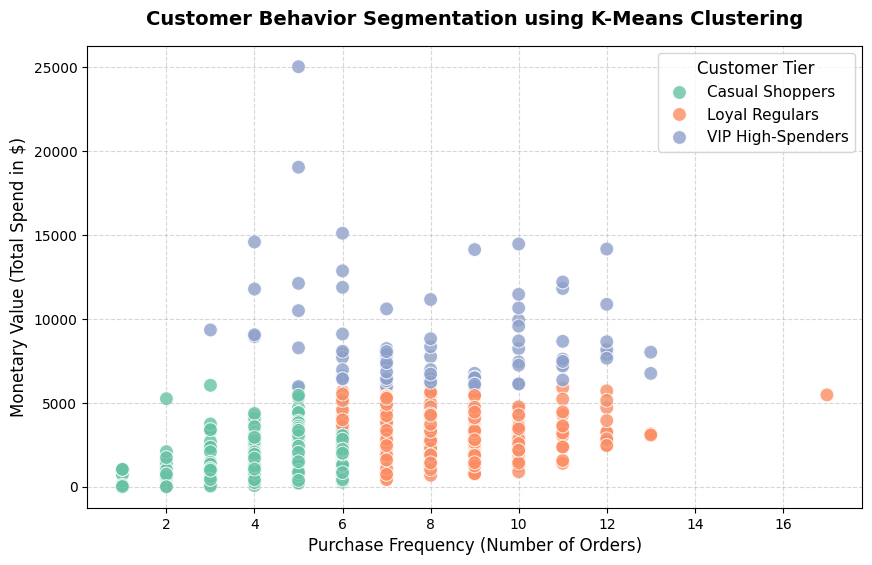

=== CUSTOMER SEGMENTATION SUMMARY ===
                   Total Count  Frequency  Monetary
Segment                                            
Casual Shoppers            422       4.35   1603.31
Loyal Regulars             292       8.36   3035.24
VIP High-Spenders           79       8.16   8843.63


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load and clean the dataset
df = pd.read_csv('train.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')
df = df.dropna(subset=['Order Date'])

# 2. Transform transaction data into Customer Behavior Metrics
customer_df = df.groupby('Customer ID').agg({
    'Order ID': 'nunique',  # Frequency: Total unique orders placed
    'Sales': 'sum'          # Monetary Value: Total money spent
}).reset_index()
customer_df.columns = ['Customer ID', 'Frequency', 'Monetary']

# 3. Standardize data scales (Crucial step for Machine Learning models)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_df[['Frequency', 'Monetary']])

# 4. Apply K-Means Clustering Machine Learning Algorithm
# We are breaking customers into 3 logical business clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_df['Cluster'] = kmeans.fit(scaled_features).labels_

# 5. Map cluster numbers to meaningful business segment names
cluster_map = {
    0: "Loyal Regulars",
    1: "Casual Shoppers",
    2: "VIP High-Spenders"
}
customer_df['Segment'] = customer_df['Cluster'].map(cluster_map)

# 6. Generate a stunning Customer Segmentation Chart
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=customer_df,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    palette='Set2',
    s=100,
    alpha=0.8
)

# Customize the chart look
plt.title('Customer Behavior Segmentation using K-Means Clustering', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Purchase Frequency (Number of Orders)', fontsize=12)
plt.ylabel('Monetary Value (Total Spend in $)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Customer Tier', fontsize=11, title_fontsize=12)

# Save the plot image automatically to your file sidebar
plt.savefig('customer_clusters.png', bbox_inches='tight', dpi=300)
plt.show()

# 7. Print summary metrics for each profile
print("=== CUSTOMER SEGMENTATION SUMMARY ===")
summary = customer_df.groupby('Segment').agg({
    'Customer ID': 'count',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).rename(columns={'Customer ID': 'Total Count'})
print(summary.round(2))